## Error de reconstrucción por clase

Usando mnist como dataset
Encontrados 15 pares de modelos.
cvae_int_128_lat_2
cvae_int_256_lat_128
cvae_int_256_lat_2
cvae_int_256_lat_64
cvae_int_512_lat_10
cvae_int_512_lat_128
cvae_int_512_lat_20
cvae_int_512_lat_256
cvae_int_512_lat_2
cvae_int_512_lat_30
cvae_int_512_lat_40
cvae_int_512_lat_64
cvae_int_512_lat_80
cvae_int_512_lat_90
cvae_int_784_lat_784


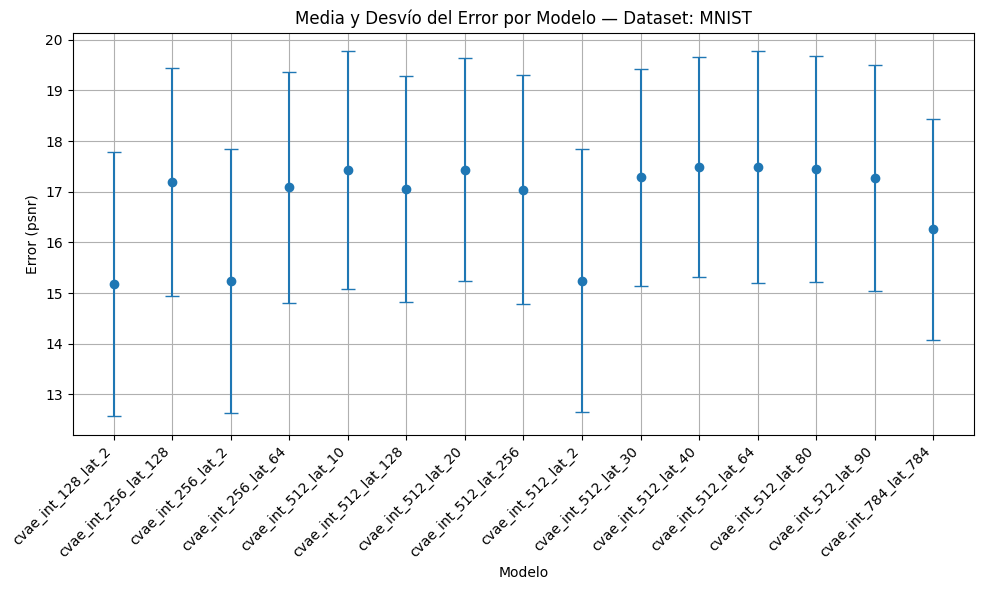

In [6]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import load
from project.metrics.metrics import Metrics 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
dataset = "mnist"

data = load.data(dataset=dataset)

models = load.all_models(dataset=dataset)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
metric = "psnr"
idx = 0
n_pictures = 1000
errores = []  # lista de filas, cada fila = un modelo

for m in models:

    print(m.name)

    errores_modelo = []   # fila de errores para este modelo

    for idx in range(n_pictures):
        x = x_test[idx : idx + 1]  # (1, 28, 28)
        y = y_test[idx : idx + 1]  # (1, 10)

        # Codificar
        z_mean, _, z = m.encoder.predict([x, y], verbose=0)

        # Decodificar
        x_recon = m.decoder.predict([z, y], verbose=0)

        # Calcular error
        if metric == "psnr":
             error_value = Metrics.psnr_grayscale(target=x, preds=x_recon)
        else:
            error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)   
           
        errores_modelo.append(error_value)

    errores.append(errores_modelo)
    
    x_pic = tf.reshape(x, (28, 28))
    x_recon = tf.reshape(x_recon, (28, 28))



import numpy as np
import matplotlib.pyplot as plt

errores_np = np.array(errores)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

# Obtener nombres de modelos sin el sufijo del dataset
model_names = [m.name.replace(f"_{dataset}.keras", "") for m in models]

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {dataset.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Error ({metric})")
plt.grid(True)

# Usar nombres como ticks
plt.xticks(x, model_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()




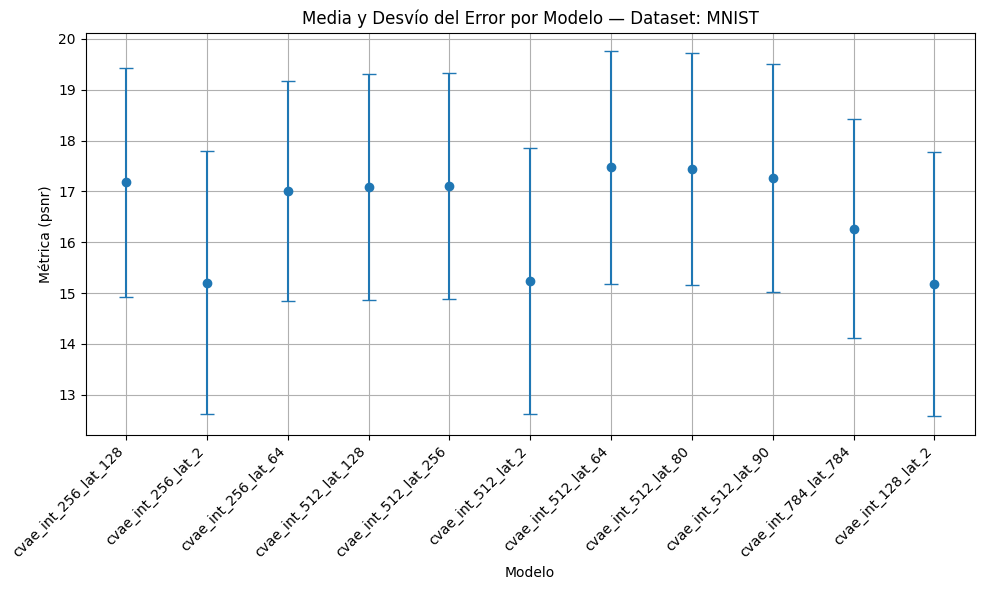

In [4]:
import numpy as np
import matplotlib.pyplot as plt

errores_np = np.array(errores)
errores_np = np.roll(errores_np, -1, axis=0)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

# Obtener nombres de modelos sin el sufijo del dataset
model_names = [m.name.replace(f"_{dataset}.keras", "") for m in models]
model_names = np.roll(model_names, -1)

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {dataset.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Métrica ({metric})")
plt.grid(True)


plt.xticks(x, model_names, rotation=45, ha="right")
plt.tight_layout()
#plt.savefig(f"error_de_reconstruccion_modelos_inter_variable_lat_128_{dataset}.png")
plt.show()




## Error por clase

In [3]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import load
from project.metrics.metrics import Metrics 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
dataset = "mnist"

data = load.data(dataset=dataset)

model = load.cvae(inter=20,lat=128,dataset=dataset)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
idx = 0
n_pictures = 1
errores = []  # lista de filas, cada fila = un modelo


errores_modelo = []   # [(clase, error), ...]

for idx in range(n_pictures):
    x = x_test[idx : idx + 1]
    y = y_test[idx : idx + 1]

    # Codificar
    z_mean, _, z = model.encoder.predict([x, y], verbose=0)

    # Decodificar
    x_recon = model.decoder.predict([z, y], verbose=0)

    # Calcular clase y error
    clase = int(np.argmax(y))
    error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)

    errores_modelo.append((clase, error_value))

errores.append(errores_modelo)



Usando mnist como dataset


### calculo

In [4]:
def estadisticas_por_clase(errores_modelo, num_clases=10):
    # errores_modelo = [(clase, error), ...]
    
    agrupados = {c: [] for c in range(num_clases)}
    for c, e in errores_modelo:
        agrupados[c].append(e)
    
    means = np.array([np.mean(agrupados[c]) for c in range(num_clases)])
    stds  = np.array([np.std(agrupados[c]) for c in range(num_clases)])
    return means, stds



### gráfico

/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


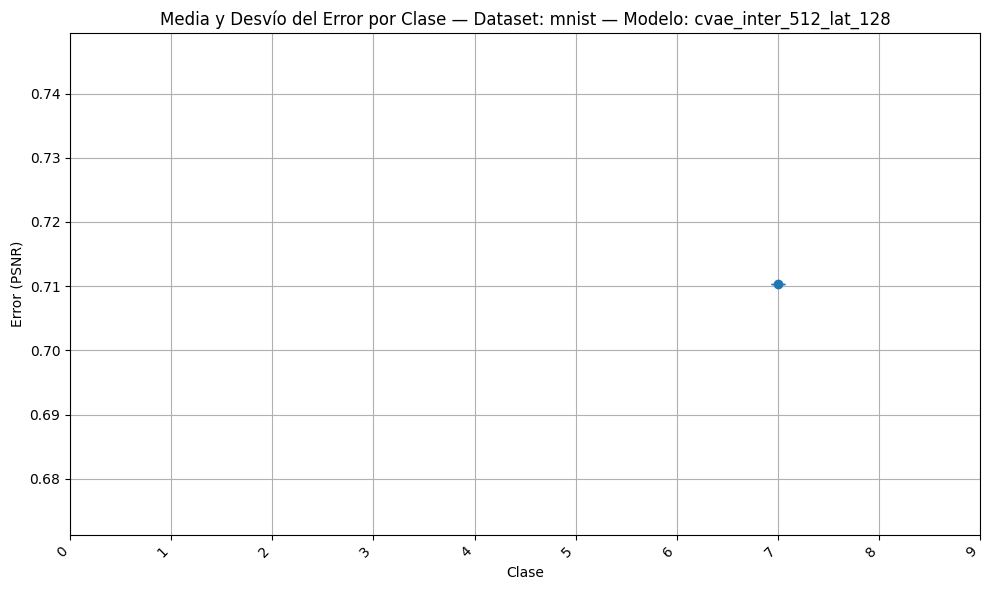

In [5]:
modelo_idx = 0   # elegí el modelo que quieras graficar
errores_modelo = errores[modelo_idx]

means, stds = estadisticas_por_clase(errores_modelo)

clases = np.arange(len(means))

#labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
labels = ["0","1","2","3","4","5","6","7","8","9"]

plt.figure(figsize=(10, 6))
plt.errorbar(clases, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Clase — Dataset: {dataset} — Modelo: cvae_inter_512_lat_128")
plt.xlabel("Clase")
plt.ylabel("Error (PSNR)")
plt.grid(True)

plt.xticks(clases, labels, rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("ssim_reconstruccion_por_clase_mnist_inter_512_lat_128")
plt.show()


__________________________________
___________________________________
